# 08 · The meter

Every chapter in this repo makes the *same* claim about the *same* incidents: that as
you hand the system higher-level intent, something changes in the gap between what you
asked for and what you got. This notebook is the instrument that measures that gap, so
the claim can be checked instead of believed.

Three numbers do the work:

| | what it asks | what a high value means |
|---|---|---|
| **outcome variance** | run the same incident N times — how much do the *answers* move? | you cannot predict what you will get |
| **process variance** | …how much does the *execution graph itself* move? | the system is deciding its own shape |
| **recall / precision** | did it find the planted root cause, or chase the red herring? | — |

Outcome variance is blast radius. Process variance is the thing people mean when they
say "dynamic". Keeping them apart is the entire point of the instrument: a system can
be wildly unpredictable in what it *does* while being perfectly stable in what it
*concludes*, and that combination is the one worth building toward.

> ### ⚠️ These are fixtures, not results
>
> The traces below are **hand-authored** to exercise the metrics. They prove the
> instrument can *see* the story. They are **not evidence for it.**
>
> The real curve gets written here once chapters 01–07 run against the incident corpus,
> and it is entirely possible it comes out a different shape. If it does, this notebook
> shows what actually happened — that is what the instrument is for.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
from meter.blast_radius import (load_runs, load_ground_truth,
                                ladder_table, ladder_plot, save_plot)

HERE  = pathlib.Path.cwd().parent / "meter"
runs  = load_runs(HERE / "fixtures/runs.json")
truth = load_ground_truth(HERE / "fixtures/ground_truth.json")

print(f"{len(runs)} traces  ·  {len(set(r['rung'] for r in runs))} rungs  "
      f"·  {len(set(r['input_id'] for r in runs))} incidents  "
      f"·  {sum(len(v) for v in truth.values())} planted defects")

126 traces  ·  7 rungs  ·  3 incidents  ·  21 planted defects


## The ladder

One row per rung. Variance is measured *within* an `input_id` — the same incident run
repeatedly — so it isolates the system's own instability from the fact that different
incidents are differently hard.

In [2]:
pd.set_option("display.width", 200, "display.max_columns", 30,
              "display.float_format", lambda v: f"{v:7.3f}")
df = ladder_table(runs, truth)
df

,altitude,runs,recall,precision,outcome_variance,count_cv,severity_cv,process_variance,cost_usd,wall_time_s,touchpoints,escalations
rung,,,,,,,,,,,,
r1,1,18,0.331,0.796,0.304,0.168,0.108,0.000,0.052,14.928,0.889,0.167
r2,2,18,0.524,0.650,0.682,0.183,0.157,0.126,0.197,47.461,2.056,0.556
r3,3,18,0.621,0.551,0.749,0.236,0.228,0.626,0.713,133.217,2.944,1.500
r4,4,18,0.669,0.856,0.405,0.095,0.077,0.000,0.333,63.711,1.056,0.167
r5,5,18,0.813,0.830,0.330,0.096,0.059,0.076,0.463,81.261,1.000,0.611
r6,6,18,0.855,0.871,0.229,0.026,0.096,0.406,0.689,104.639,0.611,0.222
r7,7,18,0.911,0.904,0.123,0.084,0.020,0.441,0.888,120.244,0.000,0.722


## What the numbers say

Read the two variance columns against each other rather than in isolation.

In [3]:
lo, hi = df.loc["r3"], df.loc["r6"]
print(f"r3  outcome {lo.outcome_variance:.3f}  process {lo.process_variance:.3f}"
      f"   -> the answers move, the method doesn't")
print(f"r6  outcome {hi.outcome_variance:.3f}  process {hi.process_variance:.3f}"
      f"   -> the method moves, the answers don't")
print()
print(f"r4 process variance = {df.loc['r4'].process_variance:.3f}  "
      "(a written-down process runs the same way every time, by construction)")
print(f"r4 vs r3: cost ${df.loc['r4'].cost_usd:.2f} vs ${df.loc['r3'].cost_usd:.2f}, "
      f"recall {df.loc['r4'].recall:.2f} vs {df.loc['r3'].recall:.2f}"
      "   -> structure was cheaper AND better")

r3  outcome 0.749  process 0.626   -> the answers move, the method doesn't
r6  outcome 0.229  process 0.406   -> the method moves, the answers don't

r4 process variance = 0.000  (a written-down process runs the same way every time, by construction)
r4 vs r3: cost $0.33 vs $0.71, recall 0.67 vs 0.62   -> structure was cheaper AND better


The crossing is the claim worth arguing about. Below it, the process is fixed and the
answers wobble — which is the ordinary experience of pointing an agent at a hard problem
and running it twice. Above it, the process is generated fresh for each incident and the
answers converge.

That is the exact inversion of how compiled software behaves. There the program is
fixed and the outputs vary with the input; here, past a certain altitude, the program
varies and the output holds still.

saved: /Users/santoshkumar/blast-radius/assets/ladder.png


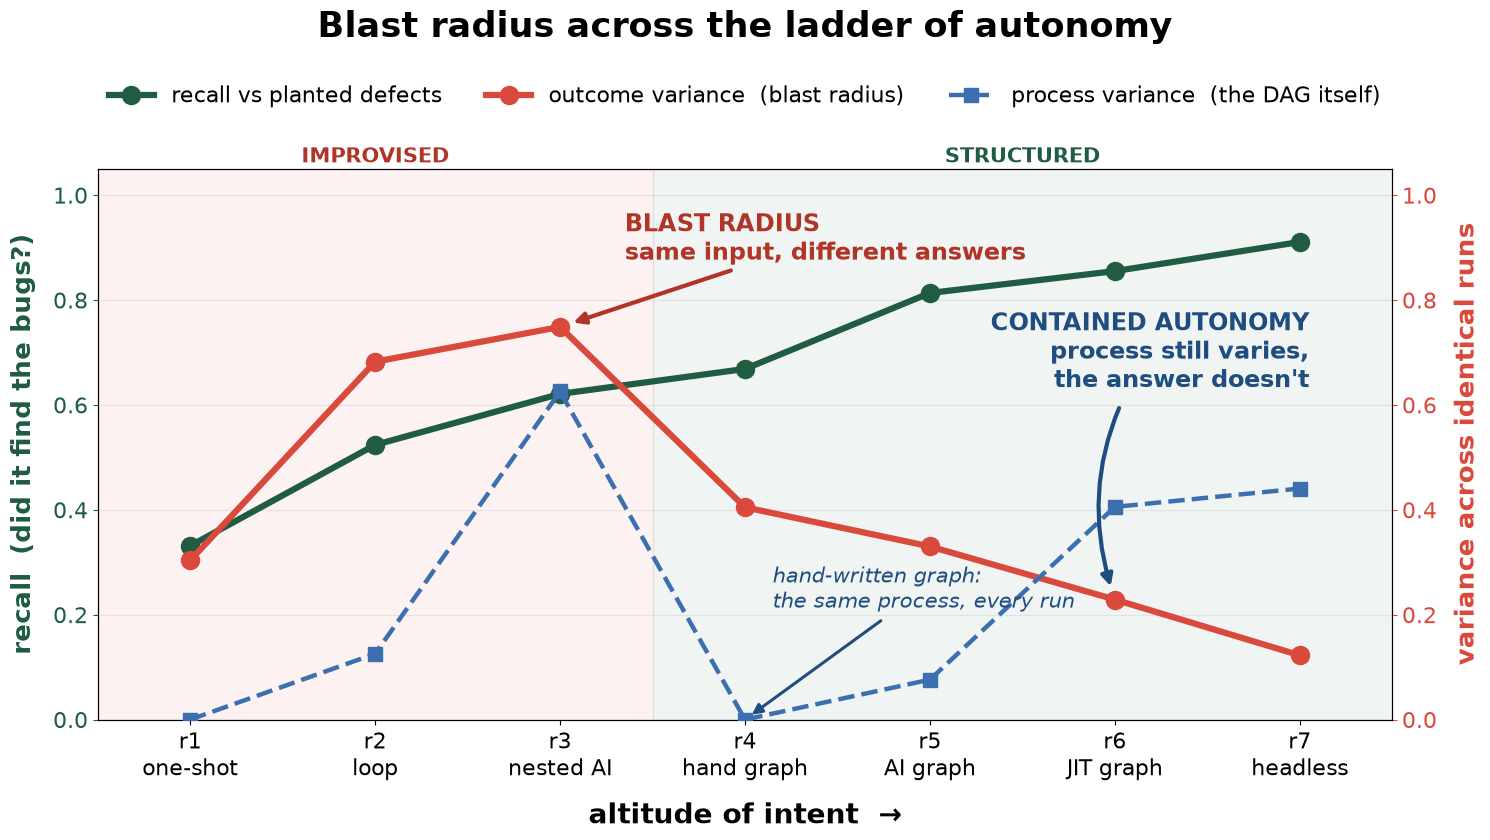

In [4]:
%matplotlib inline
fig = ladder_plot(df)
out = save_plot(fig, pathlib.Path.cwd().parent / "assets/ladder.png")
print("saved:", out)
fig

## Emitting traces from your own runs

Each rung writes one JSON object per run. `validate_run` is the contract — call it from
each chapter's tests and the meter will read anything that passes.

`dag.nodes[].label` is load-bearing: process variance compares label multisets and
label-to-label edges, so node ids can be random, but **labels must come from a stable
vocabulary across runs** or a fixed graph won't score zero.

In [5]:
from meter.blast_radius import validate_run
import json

example = runs[0]
print(json.dumps({**example, "findings": example["findings"][:1]}, indent=2)[:900], "...")
print("\nvalidate_run ->", validate_run(example) or "no errors")

{
  "rung": "r1",
  "input_id": "svc-auth",
  "run_id": "r1/svc-auth/000",
  "findings": [
    {
      "id": "f1",
      "location": "auth/login.py:89",
      "claim": "possible issue: password compared with == allowing timing attack",
      "severity": "high"
    }
  ],
  "cost_usd": 0.0569,
  "tokens": 2088,
  "wall_time_s": 10.6,
  "human_touchpoints": 1,
  "escalations": [],
  "dag": {
    "nodes": [
      {
        "id": "n0",
        "label": "audit"
      }
    ],
    "edges": []
  }
} ...

validate_run -> no errors
